# Spotify Popularity Prediction Project

This project explores Spotify audio features and uses machine learning models to predict track popularity.

## Data Loading and Cleaning

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

os.makedirs("images", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [33]:
df = pd.read_csv("spotify_tracks.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [34]:
df.shape

(114000, 22)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  11

In [36]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name',
       'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [37]:
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])

df = df.drop_duplicates(subset="track_id")

df = df.dropna()

df["duration_min"] = df["duration_ms"] / 60000 # create a new column

df.shape

(89740, 21)

In [7]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min
count,89740.000000,8.974000e+04,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000
mean,33.198808,2.291444e+05,0.562166,0.634458,5.283530,-8.498994,0.636973,0.087442,0.328285,0.173415,0.216971,0.469474,122.058134,3.897426,3.819073
std,20.580640,1.129458e+05,0.176692,0.256606,3.559912,5.221518,0.480875,0.113278,0.338321,0.323849,0.194885,0.262864,30.117651,0.453437,1.882430
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.143100
25%,19.000000,1.730400e+05,0.450000,0.457000,2.000000,-10.322250,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.262750,4.000000,2.884000
50%,33.000000,2.132955e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000,3.554925
75%,49.000000,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097625,0.279000,0.682000,140.077000,4.000000,4.404883
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,87.288250


## Popularity Distribution Graph

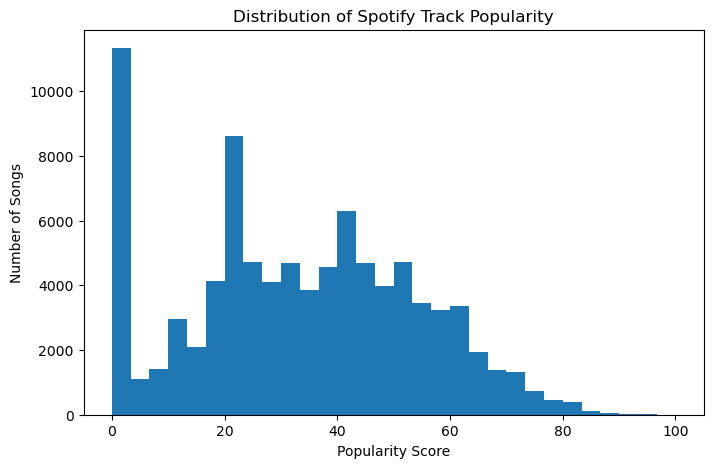

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["popularity"], bins=30)

plt.xlabel("Popularity Score")
plt.ylabel("Number of Songs")
plt.title("Distribution of Spotify Track Popularity")

# Save figure
plt.savefig("images/popularity_distribution.png",
            bbox_inches="tight")

plt.show()

## Genre Popularity Analysis

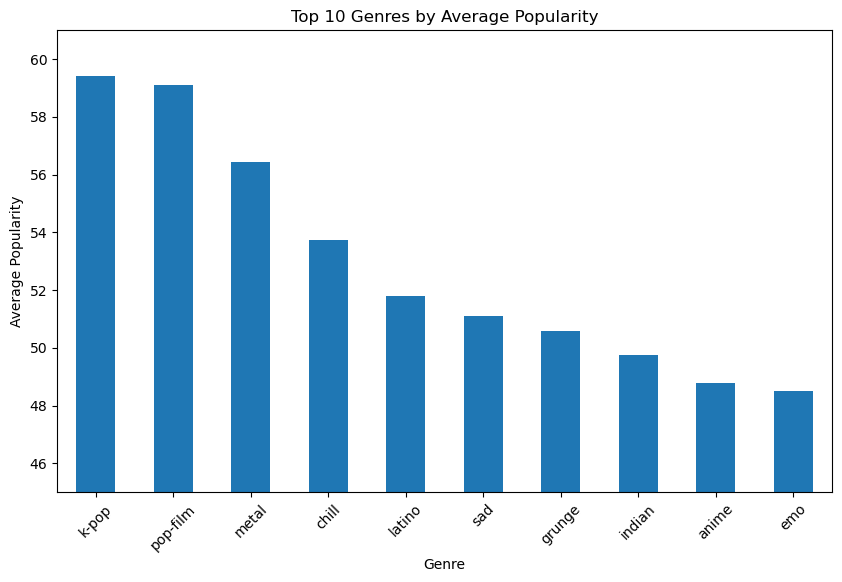

In [38]:
genre_popularity = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

genre_popularity.plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.title("Top 10 Genres by Average Popularity")

plt.ylim(45, 61)

plt.xticks(rotation=45)

plt.savefig("images/top_genres_popularity.png",
            bbox_inches="tight")

plt.show()

## Machine Learning Model

In [10]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min"
]

X = df[features]

y = df["popularity"]

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,20
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Feature Importance Analysis

In [16]:
importance = rf_model.feature_importances_

importance

array([0.1118793 , 0.07730056, 0.07795445, 0.08873496, 0.17351336,
       0.13433265, 0.05111288, 0.10185161, 0.05996584, 0.12335439])

In [17]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

importance_df

,Feature,Importance
0,danceability,0.111879
1,energy,0.077301
2,loudness,0.077954
3,speechiness,0.088735
4,acousticness,0.173513
5,instrumentalness,0.134333
6,liveness,0.051113
7,valence,0.101852
8,tempo,0.059966
9,duration_min,0.123354


In [19]:
# Rank:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=True
)

importance_df

,Feature,Importance
6,liveness,0.051113
8,tempo,0.059966
1,energy,0.077301
2,loudness,0.077954
3,speechiness,0.088735
7,valence,0.101852
0,danceability,0.111879
9,duration_min,0.123354
5,instrumentalness,0.134333
4,acousticness,0.173513


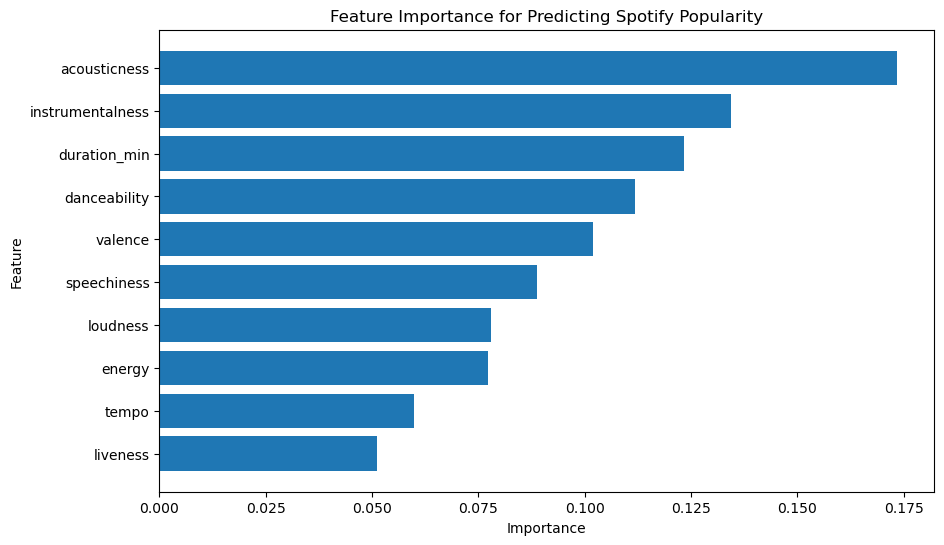

In [20]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Predicting Spotify Popularity")

# Save figure
plt.savefig(
    "images/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [21]:
y_pred = rf_model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 15.369749129793572
R² Score: 0.1252908911752163


## Correlation Heatmap

In [29]:
corr_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min"
]

corr_matrix = df[corr_features].corr()

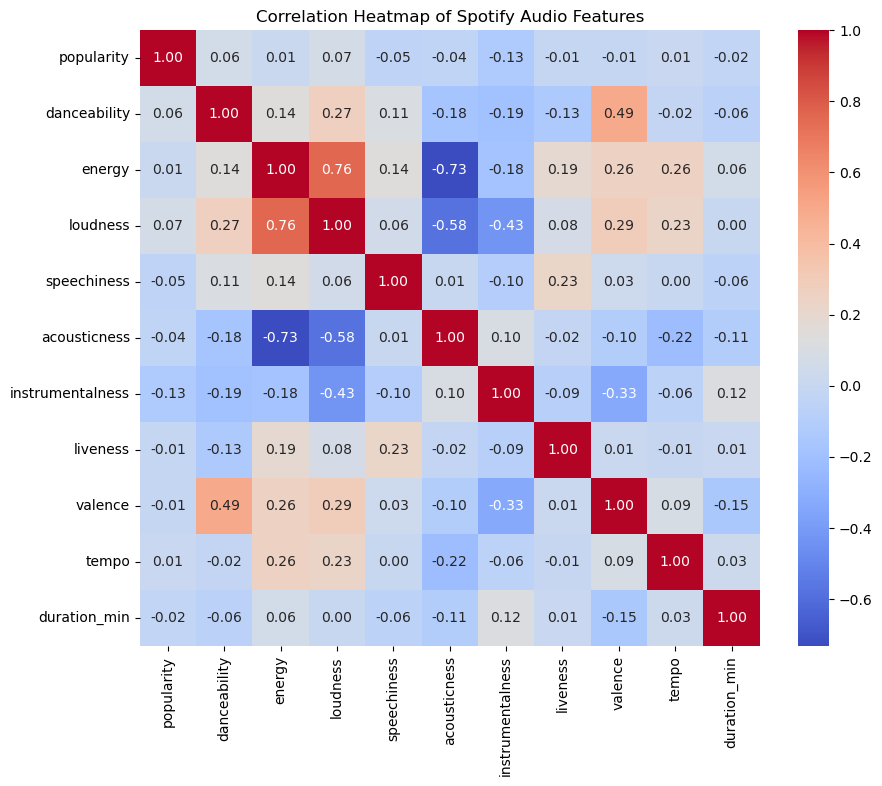

In [30]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Spotify Audio Features")

# Save figure
plt.savefig(
    "images/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

## Conclusion

The project explored relationships between Spotify audio features and track popularity using exploratory data analysis and Random Forest models.

Results showed that features such as loudness, energy, and danceability contributed to popularity prediction, but overall model performance remained limited (R² ≈ 0.12). This suggests that song popularity depends on many external factors beyond audio features alone.